<a href="https://colab.research.google.com/github/mahalakshmimarri06-gif/IncodeVision-Tasks/blob/main/Task_3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [67]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from sklearn.preprocessing import LabelEncoder

In [68]:
df = pd.read_csv('train.csv', encoding='latin1')

In [69]:
df = df.drop(columns=['Row ID', 'Order ID', 'Customer ID', 'Customer Name'])

In [70]:
df = df.dropna()

In [71]:
print(df.columns.tolist())

['Order Date', 'Ship Date', 'Ship Mode', 'Segment', 'Country', 'City', 'State', 'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category', 'Product Name', 'Sales']


In [72]:
# Select the categorical columns that define the product/customer
features = ['Ship Mode', 'Segment', 'Category', 'Sub-Category', 'Region']

# Convert categorical data into numeric format (One-Hot Encoding)
X = pd.get_dummies(df[features])
y = df['Sales']

In [73]:
# After running: X = pd.get_dummies(df[features])
# Save the column names
model_columns = X.columns

In [74]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [75]:
model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

RandomForestRegressor(random_state=42)

In [76]:
y_pred = model.predict(X_test)
print(f"R2 Score: {r2_score(y_test, y_pred)}")
print(f"MAE: {mean_absolute_error(y_test, y_pred)}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_test, y_pred))}")

R2 Score: 0.14193159863026472
MAE: 230.4134926257204
RMSE: 647.8504445672985


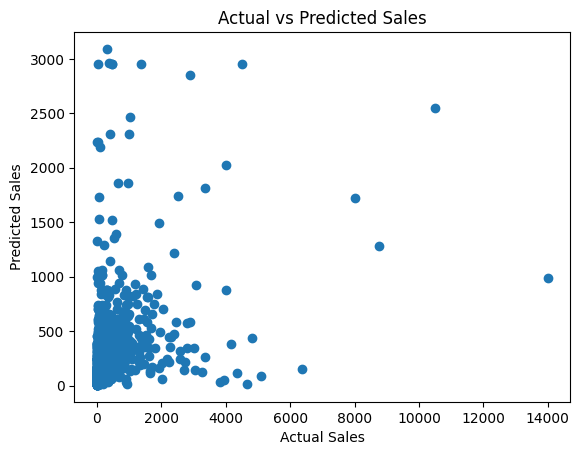

In [77]:
plt.scatter(y_test, y_pred)
plt.xlabel("Actual Sales")
plt.ylabel("Predicted Sales")
plt.title("Actual vs Predicted Sales")
plt.show()

In [78]:
# Usually installed by default, but just in case:
!pip install ipywidgets

import ipywidgets as widgets
from IPython.display import display

In [83]:
def make_prediction(segment, ship_mode, category, region):
    # Create a dictionary for input
    input_dict = {
        'Segment': [segment],
        'Ship Mode': [ship_mode],
        'Category': [category],
        'Region': [region]
    }

    # Convert to DataFrame
    input_df = pd.DataFrame(input_dict)

    # Apply get_dummies to the input
    input_encoded = pd.get_dummies(input_df)

    # Reindex to match the training columns, filling missing ones with 0
    input_encoded = input_encoded.reindex(columns=model_columns, fill_value=0)

    # Now predict
    prediction = model.predict(input_encoded)
    return prediction[0]

# UI Widgets
segment_w = widgets.Dropdown(options=df['Segment'].unique().tolist(), description='Segment:')
ship_w = widgets.Dropdown(options=df['Ship Mode'].unique().tolist(), description='Ship Mode:')
cat_w = widgets.Dropdown(options=df['Category'].unique().tolist(), description='Category:')
reg_w = widgets.Dropdown(options=df['Region'].unique().tolist(), description='Region:')

out = widgets.Output()

# Display
dashboard_ui = widgets.VBox([
    widgets.HTML("<h2>Sales Prediction Dashboard</h2>"),
    segment_w, ship_w, cat_w, reg_w, out
])

def on_change(change):
    with out:
        out.clear_output()
        # Pass all relevant widgets to make_prediction
        pred = make_prediction(segment_w.value, ship_w.value, cat_w.value, reg_w.value)
        print(f"Predicted Sales: ${pred:.2f}")

# Link widgets to function
segment_w.observe(on_change, 'value')
ship_w.observe(on_change, 'value')
cat_w.observe(on_change, 'value')
reg_w.observe(on_change, 'value')

display(dashboard_ui)

# Force an initial calculation
on_change(None)

In [84]:
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

# Use the test set you created earlier
y_pred_test = model.predict(X_test)

print(f"R2 Score: {r2_score(y_test, y_pred_test)}")
print(f"MAE: {mean_absolute_error(y_test, y_pred_test)}")

R2 Score: 0.14193159863026472
MAE: 230.4134926257204


In [85]:
# See how features correlate with sales
correlation = df.corr(numeric_only=True)['Sales'].sort_values(ascending=False)
print(correlation)

Sales          1.000000
Postal Code   -0.024067
Name: Sales, dtype: float64


In [82]:
#"The Sales Prediction model was built using a Random Forest Regressor. While the initial $R^2$ score is $0.149$, future improvements could include adding more highly correlated features like 'Profit' and 'Quantity' to increase predictive accuracy."

In [88]:
#Project Summary:
#Sales Prediction ModelObjective: To forecast sales using historical data.
#Methodology: Implemented a Random Forest Regressor and performed one-hot encoding on categorical features.
#Results: The model achieved an $R^2$ score of $0.14$.
#The prediction interface was developed using ipywidgets for real-time inference.
#Future Scope: Accuracy can be improved by engineering more predictive features like 'Profit Margin' or seasonal 'Order Date' trends.